High Pass filter: Prewit Filter

In [1]:
import numpy as np
import imageio as io
import matplotlib.pyplot as plt
import cv2 as cv


In [2]:
#convolation function
def convolation(kernal,image):#without rotation
  #size of kernal && image
  kernal_r,kernal_c=kernal.shape
  image_r,image_c=image.shape

  #check how much padding require for img
  padding_r=kernal_r//2 # return the quotient
  padding_c=kernal_c//2

  #apply this padding on given img
  padded_img=np.pad(image,((padding_r,padding_r),(padding_c,padding_c)),mode='constant',constant_values=0)
  resultant_image=np.zeros((image_r,image_c))
  #now start convoling operation on padded image
  #select region of img accordind to mask/kernal size and apply dot product
  for i in range(image_r):
    for j in range(image_c):
       region=np.zeros((kernal_r,kernal_c))
       region=padded_img[i:i+kernal_r,j:j+kernal_c]
       #now perform dot product
       resultant_image[i,j]=np.sum(kernal*region)

  return resultant_image






In [3]:
#using built in
def convolation_built_in(kernal,image):
  resultant_image=cv.filter2D(image,-1,kernal)
  return resultant_image

In [4]:
#apply prewit filteralong x_axis , than y_axis
prewit_x=np.array([[1,0,-1],
                  [1,0,-1],
                  [1,0,-1]])

prewit_y=np.array([[1,1,1],
                  [0,0,0],
                  [-1,-1,-1]])


In [5]:
#conversion in grayscale
def grayScale(image):
  return cv.cvtColor(image,cv.COLOR_BGR2GRAY)

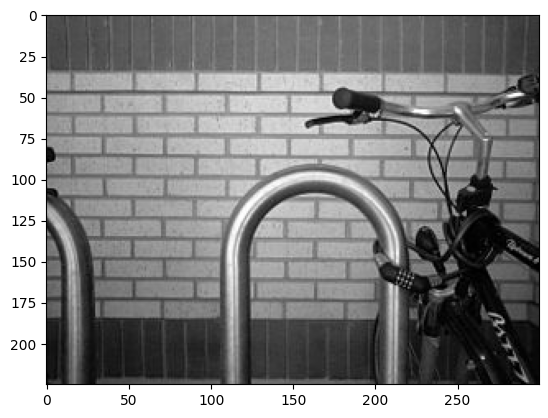

In [6]:

#read image
image=cv.imread('/content/prewit_filter.jpg')
plt.imshow(image)




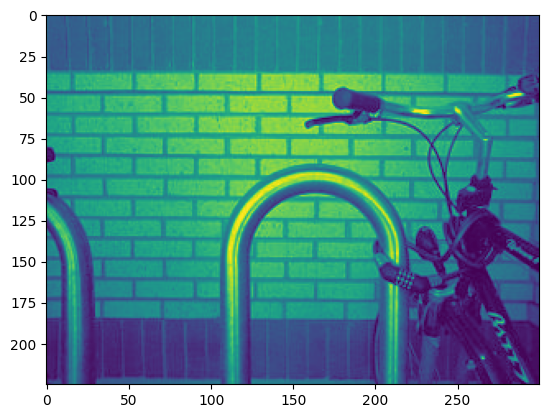

In [7]:
gray_scale_img=grayScale(image)
plt.imshow(gray_scale_img)

In [8]:
#apply the filter

resultant_image_x=convolation(prewit_x,gray_scale_img)
resultant_image_x


array([[-156.,   15.,    1., ...,   -9.,  -10.,  130.],
       [-237.,   25.,    4., ...,  -10.,  -11.,  188.],
       [-241.,   31.,    8., ...,   -2.,   -3.,  185.],
       ...,
       [ -97., -103.,  -20., ...,   47.,    5.,   11.],
       [-107., -134.,  -37., ...,   65.,   13.,   17.],
       [ -74., -102.,  -33., ...,   48.,   11.,   14.]])

In [9]:
resultant_image_y=convolation(prewit_y,gray_scale_img)
resultant_image_x

array([[-156.,   15.,    1., ...,   -9.,  -10.,  130.],
       [-237.,   25.,    4., ...,  -10.,  -11.,  188.],
       [-241.,   31.,    8., ...,   -2.,   -3.,  185.],
       ...,
       [ -97., -103.,  -20., ...,   47.,    5.,   11.],
       [-107., -134.,  -37., ...,   65.,   13.,   17.],
       [ -74., -102.,  -33., ...,   48.,   11.,   14.]])

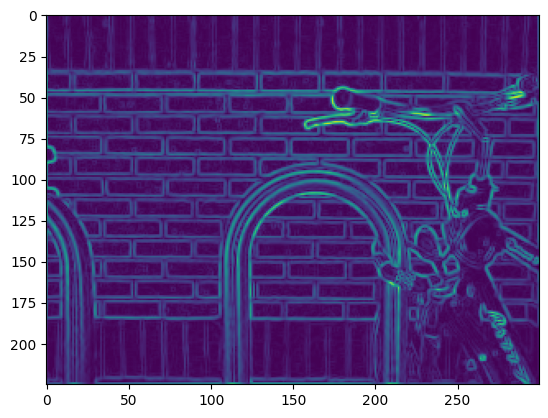

In [10]:
#take megnitude
megnitude_img=np.sqrt(np.square(resultant_image_x)+np.square(resultant_image_y))
plt.imshow(megnitude_img)

In [11]:
megnitude_img

array([[225.62136424, 239.47024867, 233.00214591, ..., 199.20341363,
        204.24495098, 189.58902922],
       [237.17082451,  27.31300057,   8.06225775, ...,  11.18033989,
         17.02938637, 188.32153355],
       [241.10163832,  31.78049716,   8.06225775, ...,  19.10497317,
         27.16615541, 186.18807695],
       ...,
       [101.53324579, 127.41271522, 110.81967334, ...,  52.77309921,
         15.8113883 ,  13.03840481],
       [108.50345617, 135.20355025,  37.65634077, ...,  71.58910532,
         20.61552813,  18.78829423],
       [ 92.20086767, 158.25612152, 173.17332358, ...,  65.11528238,
         30.08321791,  20.51828453]])

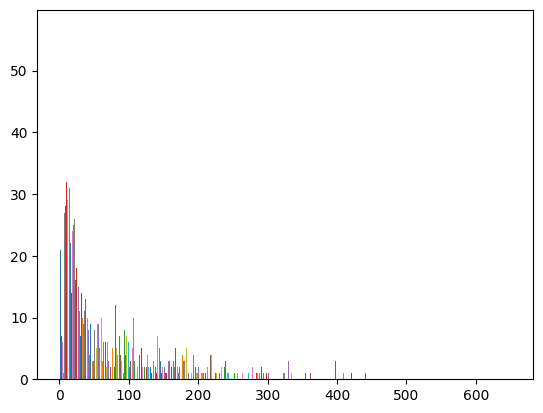

In [12]:
plt.hist(megnitude_img,bins=100)
plt.show()

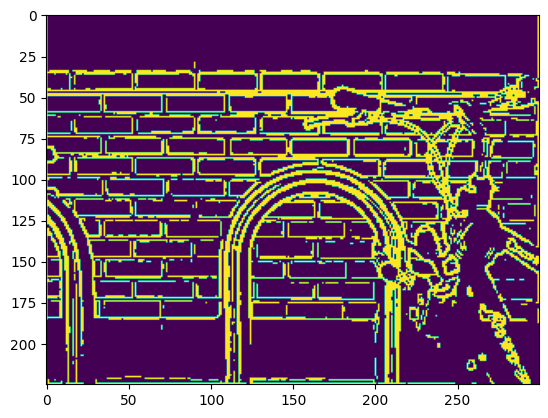

In [13]:
#let apply threshold on this megnitude image
ret,image_thres=cv.threshold(megnitude_img,120,255,cv.THRESH_BINARY)
plt.imshow(image_thres)


90.0


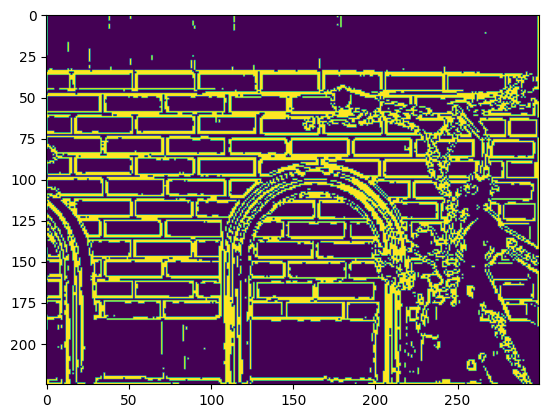

In [14]:
# Convert the image to 8-bit unsigned integer
megnitude_img_8u = megnitude_img.astype(np.uint8)
ret,ostu_thres=cv.threshold(megnitude_img_8u,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
plt.imshow(ostu_thres)
print()
print(ret)

In [15]:
#sobel filter

sobel_x=np.array([[1,0,-1],
                  [2,0,-2],
                  [1,0,-1]])

sobel_y=np.array([[1,2,1],
                  [0,0,0],
                  [-1,-2,-1]])

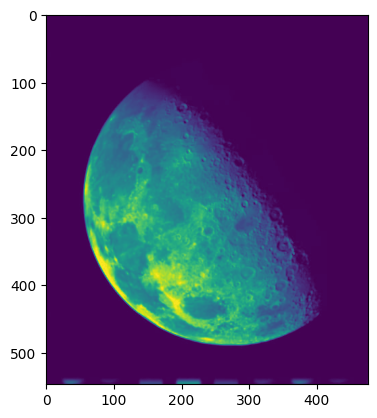

In [16]:
#convert to gray scale
moon=cv.imread('/content/moon.jpeg')
moon_gray=grayScale(moon)
plt.imshow(moon_gray)

In [17]:
#filter apply alog x,y direction
sobel_moon_x=convolation(sobel_x,moon_gray)
sobel_moon_y=convolation(sobel_y,moon_gray)


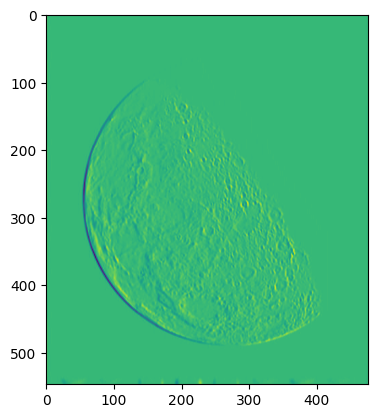

In [18]:
plt.imshow(sobel_moon_x)

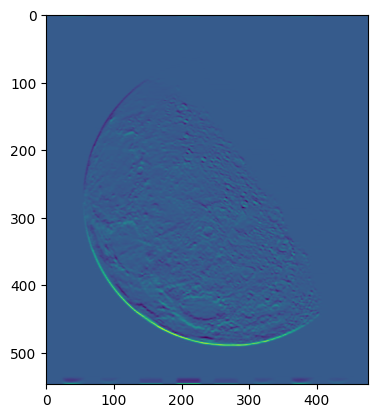

In [19]:
plt.imshow(sobel_moon_y)

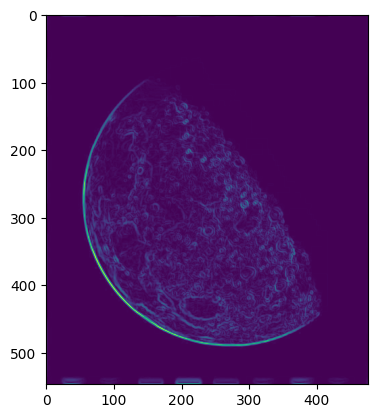

In [20]:
sobel_megnitude=np.sqrt(np.square(sobel_moon_x)+np.square(sobel_moon_y))
plt.imshow(sobel_megnitude)

In [21]:
sobel_megnitude

array([[87.86353055, 83.48652586, 58.        , ...,  3.16227766,
        10.29563014,  7.61577311],
       [72.80109889, 64.62197769, 57.5847202 , ...,  4.        ,
        12.        ,  4.        ],
       [60.92618485, 63.5295207 , 53.66563146, ...,  4.        ,
        12.        ,  4.        ],
       ...,
       [ 8.48528137,  6.32455532,  3.16227766, ..., 27.16615541,
        31.40063694, 27.45906044],
       [ 4.        ,  0.        ,  0.        , ..., 28.        ,
        32.        , 28.        ],
       [ 4.24264069,  4.        ,  4.        , ..., 24.69817807,
        36.87817783, 35.80502758]])

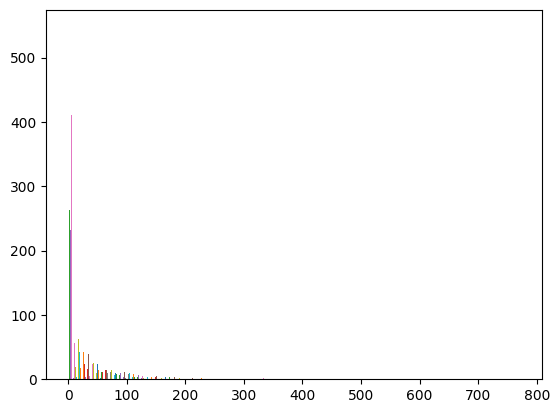

In [22]:
#histogram
plt.hist(sobel_megnitude,bins=100)
plt.show()

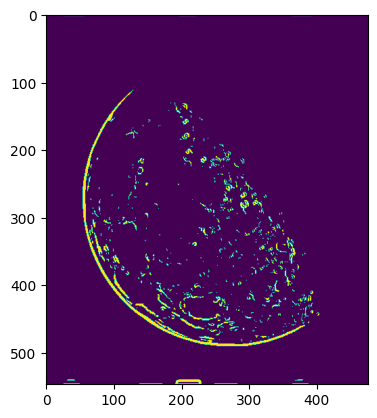

In [39]:
#let apply threshold on this megnitude image
ret,image_thres=cv.threshold(sobel_megnitude,121,255,cv.THRESH_BINARY)
plt.imshow(image_thres)



48.0


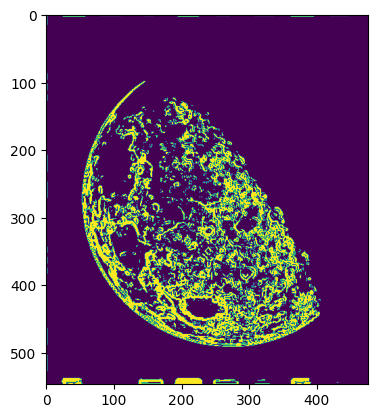

In [24]:
# Convert the image to 8-bit unsigned integer
sobel_megnitude_img_8u = sobel_megnitude.astype(np.uint8)
ret,ostu_thres=cv.threshold(sobel_megnitude_img_8u,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
plt.imshow(ostu_thres)
print()
print(ret)

Laplacian Filter

In [26]:
#laplacian filter
lap_filter=np.array([[0,1,0],
                    [1,-4,1],
                    [0,1,0]])

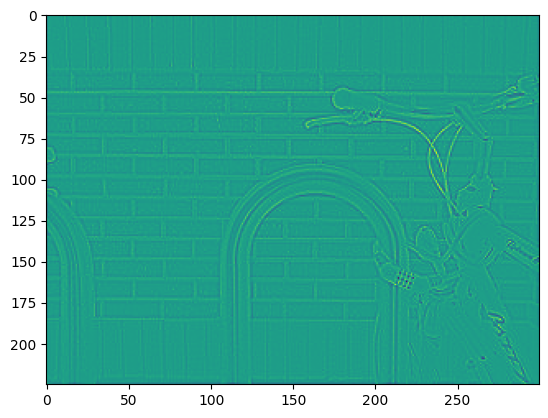

In [32]:
#apply filter
lap_image=convolation(lap_filter,gray_scale_img)
plt.imshow(lap_image)

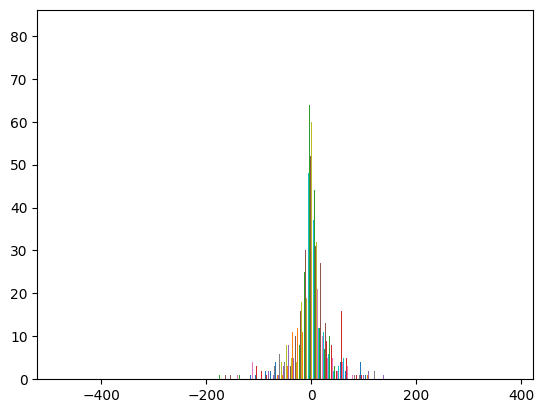

In [33]:
#histogram'
plt.hist(lap_image,bins=100)
plt.show()


0.0


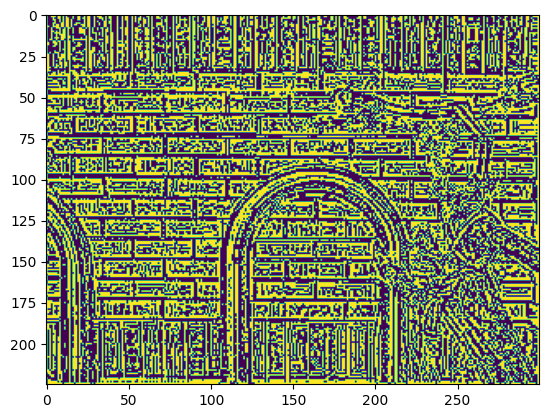

In [35]:
#threshold
lap_image_8u = lap_image.astype(np.uint8)
ret,lap_image=cv.threshold(lap_image_8u,100,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
plt.imshow(lap_image)
print()
print(ret)

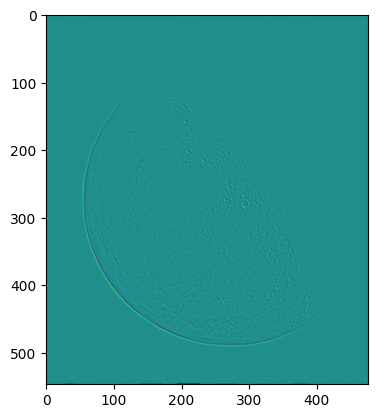

In [36]:
#exampl2
#apply filter
lap_moon_image=convolation(lap_filter,moon_gray)
plt.imshow(lap_moon_image)


121.0


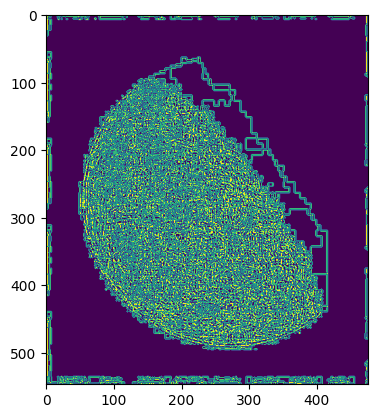

In [38]:
#threshold
lap_moon_image_8u = lap_moon_image.astype(np.uint8)
ret,lap_moon_image=cv.threshold(lap_moon_image_8u,100,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
plt.imshow(lap_moon_image)
print()
print(ret)